<a href="https://colab.research.google.com/github/drakopablo/eml_k_bandit_grupo17/blob/yolanda/egreedy_YOL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
%cd /content/eml_k_bandit_grupo17

/content/eml_k_bandit_grupo17


In [10]:
!ls

03_softmax.ipynb  bandit_experiment.ipynb  plotting	     softmax.ipynb
algorithms	  egreedy_YOL2.ipynb	   README.md
arms		  main.py		   requirements.txt


In [11]:
from arms.armnormal import ArmNormal
from algorithms.epsilon_greedy import EpsilonGreedy

BERNOULLI


===== k = 10 =====


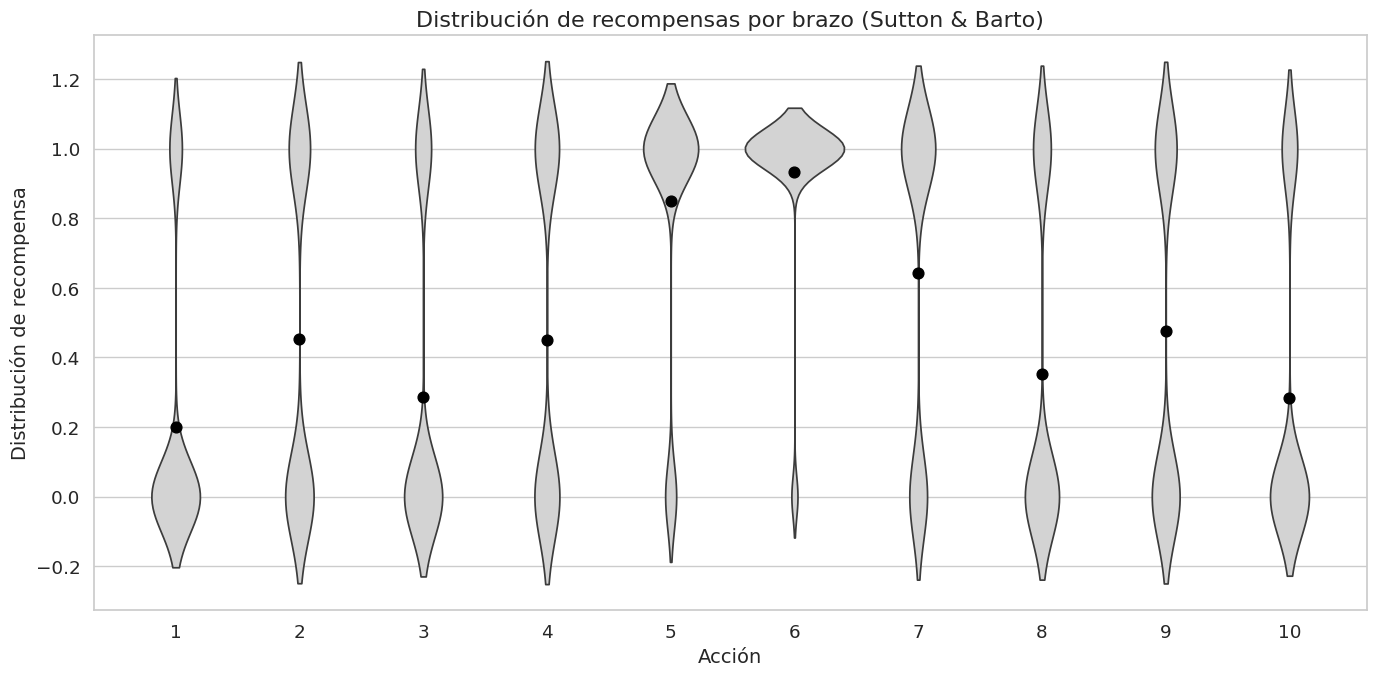

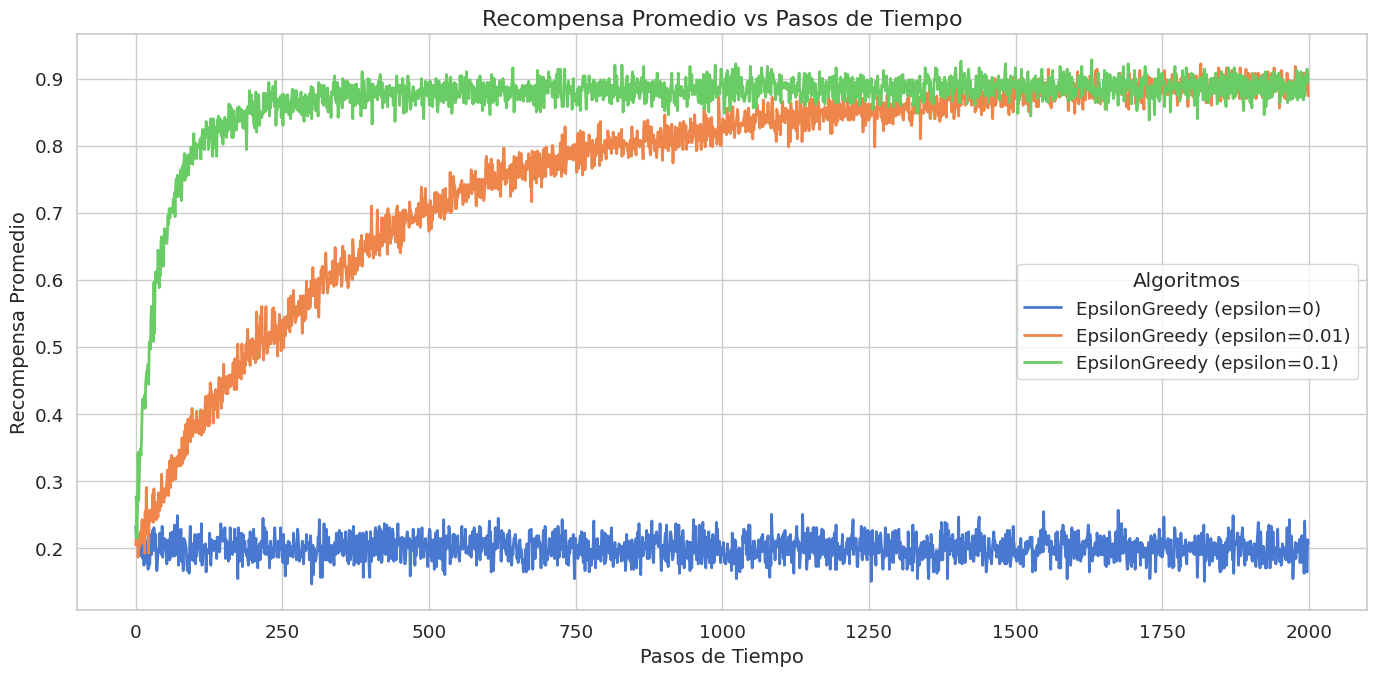

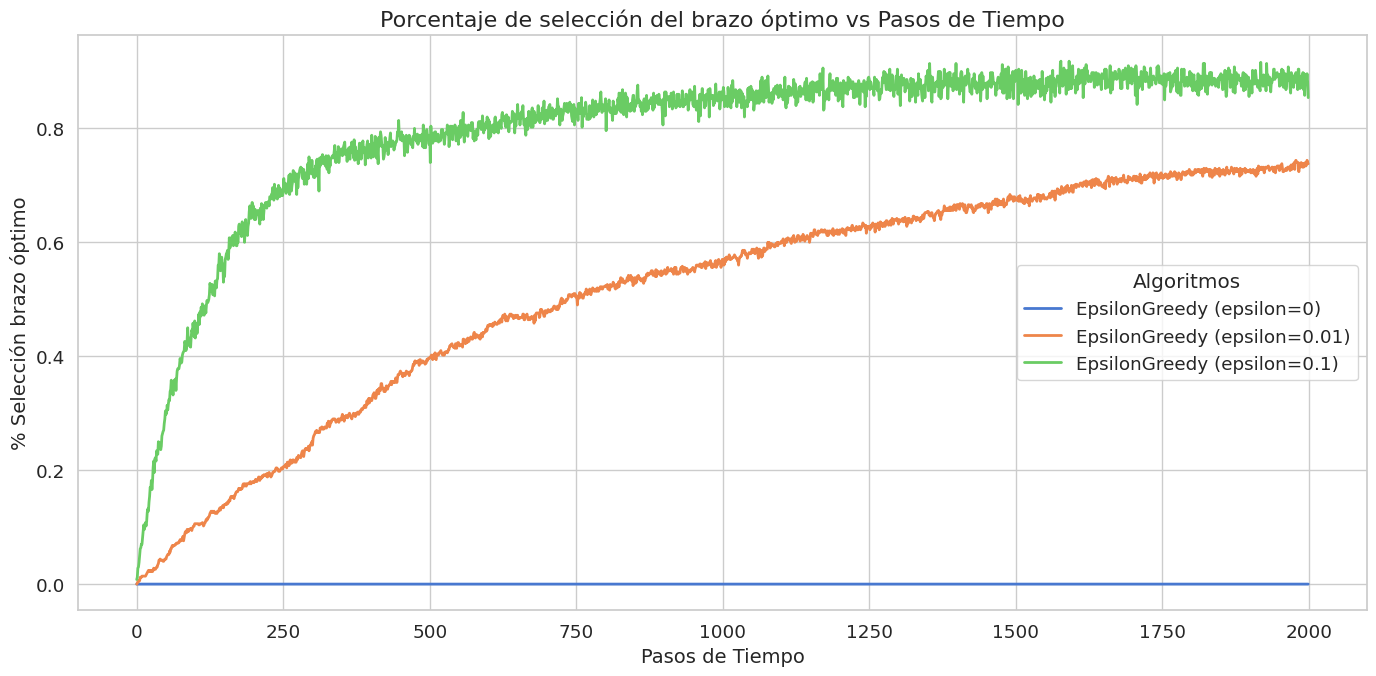


===== k = 20 =====


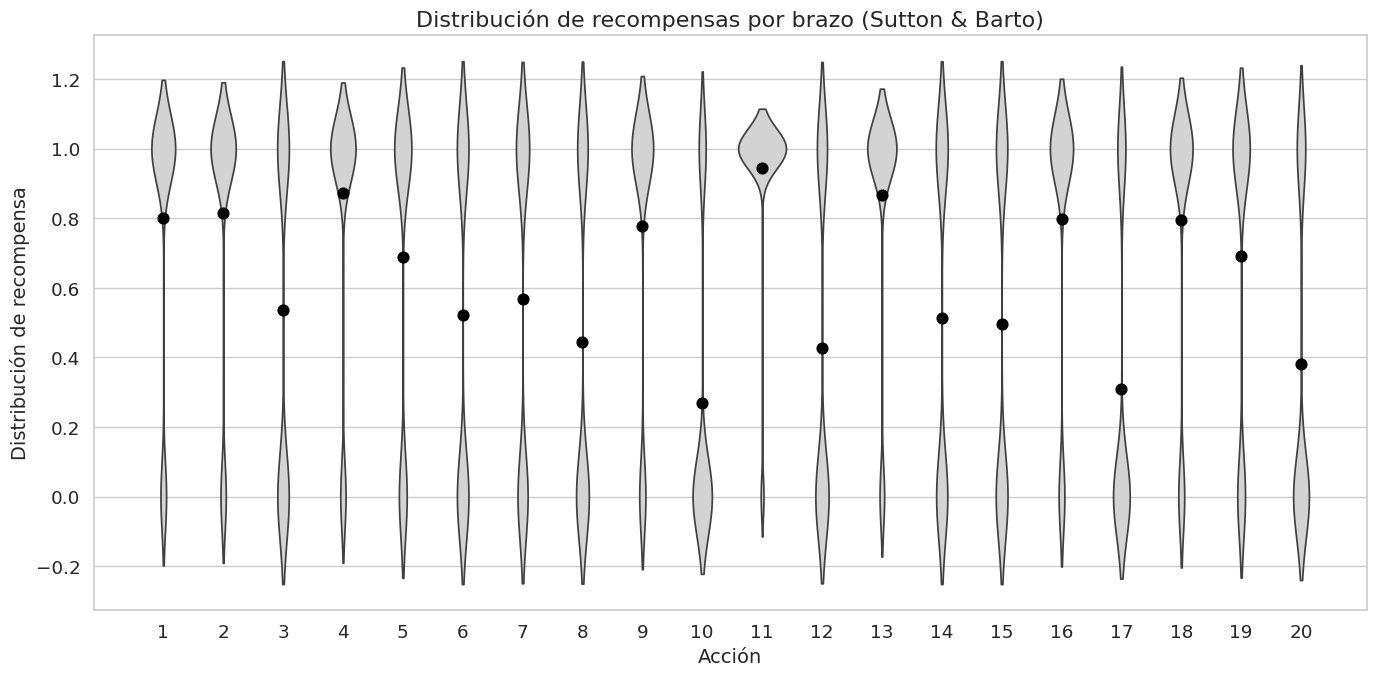

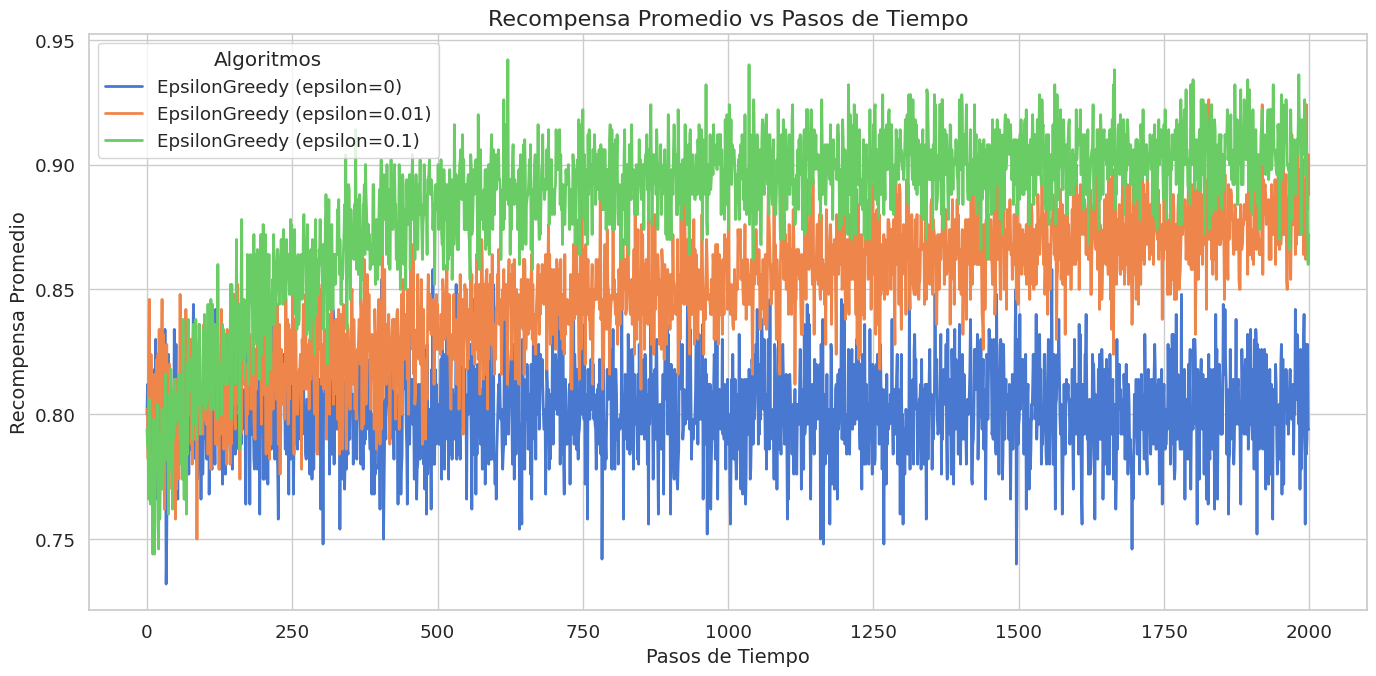

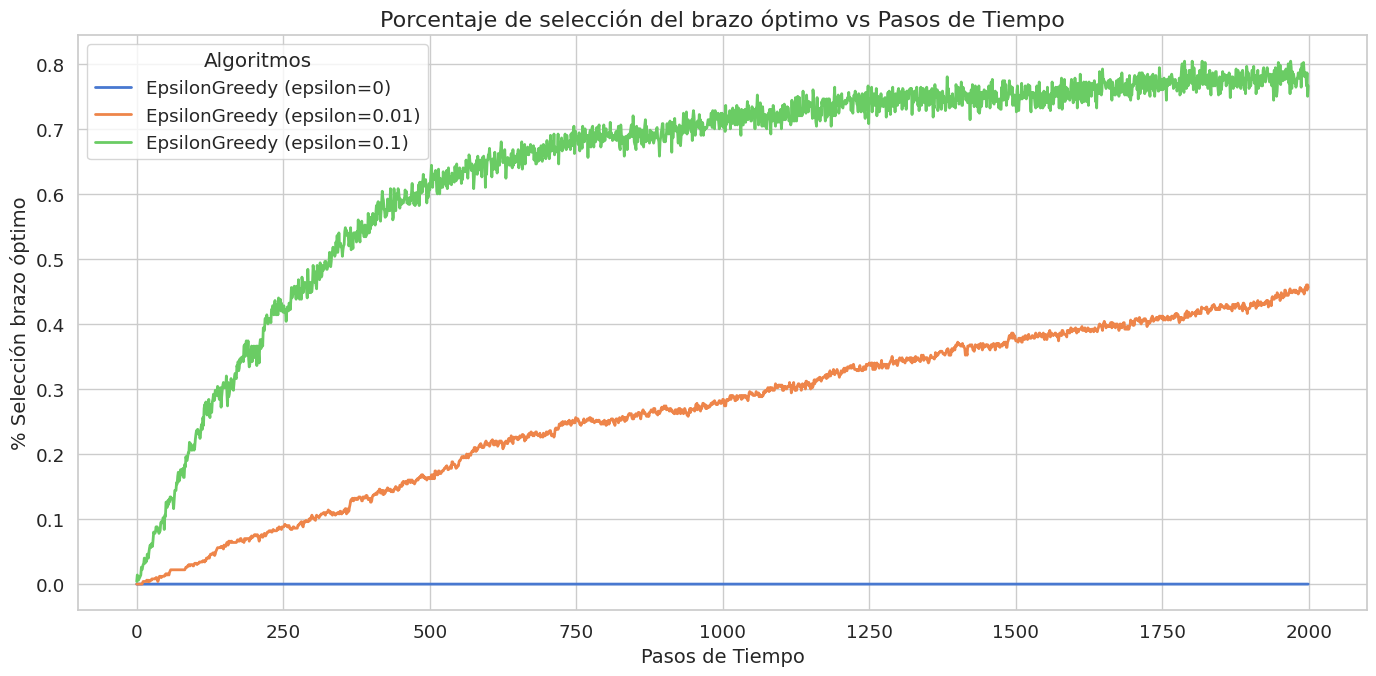


===== k = 100 =====


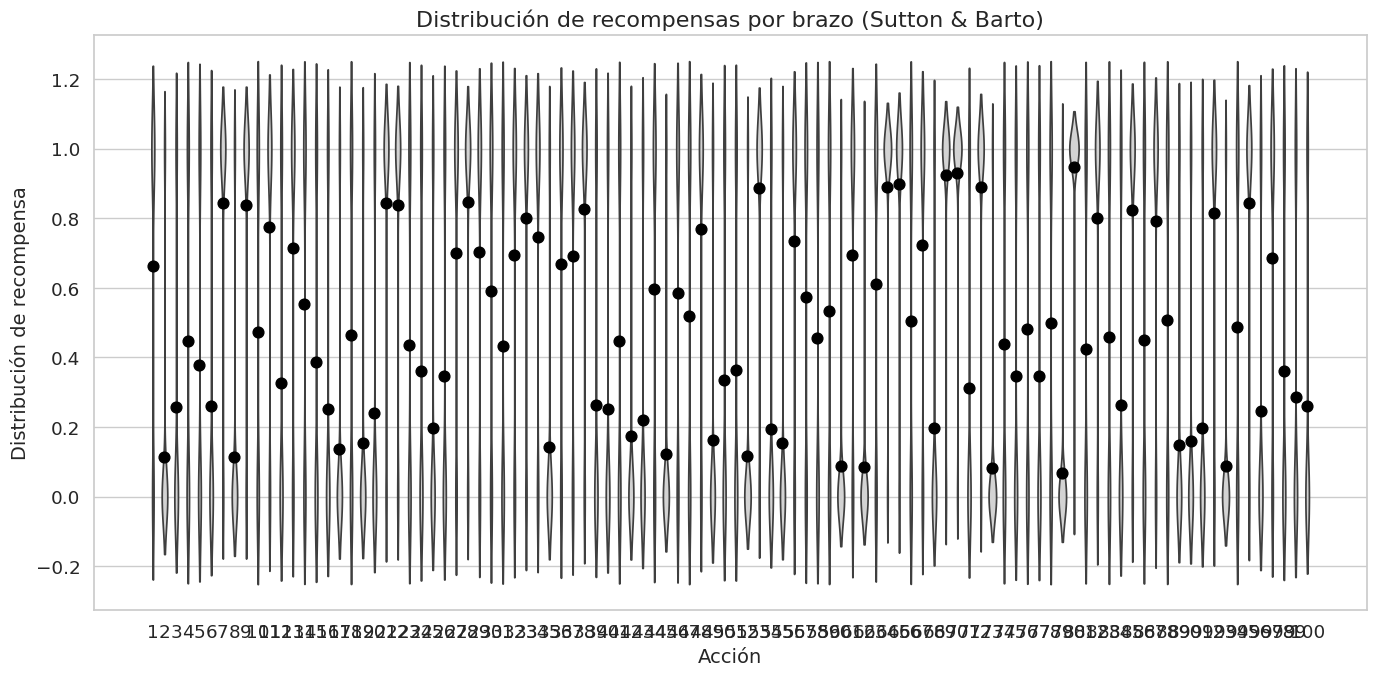

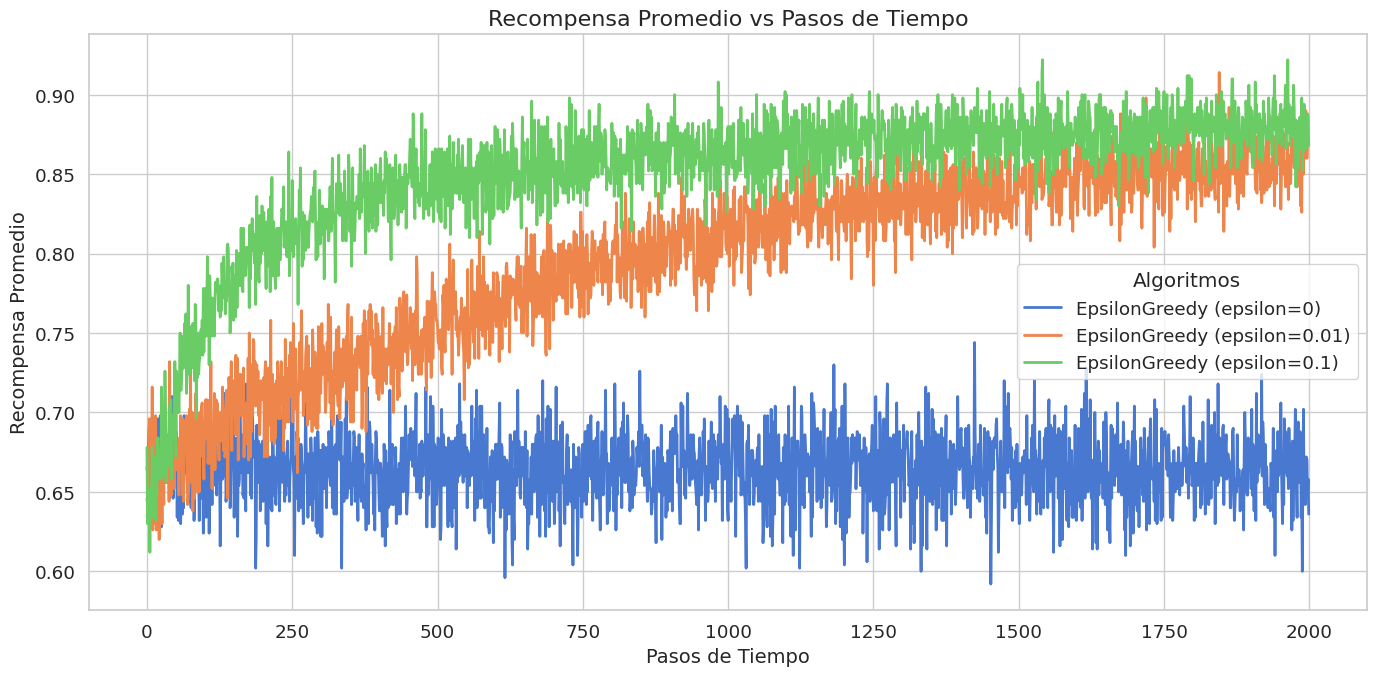

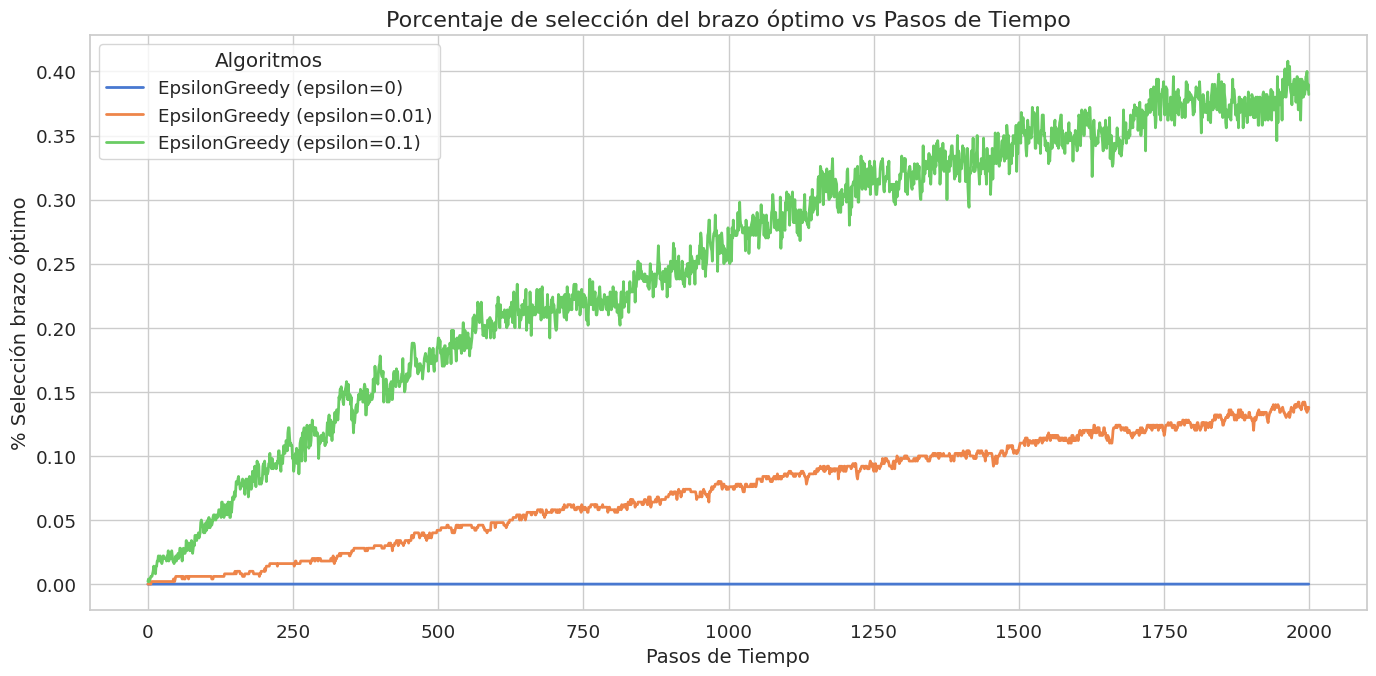

In [29]:
import numpy as np

import importlib
import plotting.sutton
importlib.reload(plotting.sutton)

from arms.armbernoulli import ArmBernoulli
from arms.bandit import Bandit
from algorithms.epsilon_greedy import EpsilonGreedy

from plotting.plotting import plot_average_rewards, plot_optimal_selections
from plotting.sutton import plot_reward_distributions


# =====================================================
# FUNCIÓN EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()

    for run in range(runs):

        # Reiniciamos algoritmos en cada run
        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs

    return rewards, optimal_selections


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Generamos probabilidades Bernoulli
    p_values = np.random.uniform(0.05, 0.95, k)
    arms = [ArmBernoulli(p) for p in p_values]

    # 🔹 Gráfica tipo Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 🔹 Gráficas oficiales del profesor
    plot_average_rewards(steps, rewards, algorithms)
    plot_optimal_selections(steps, optimal_selections, algorithms)

BINOMIAL


===== k = 10 =====


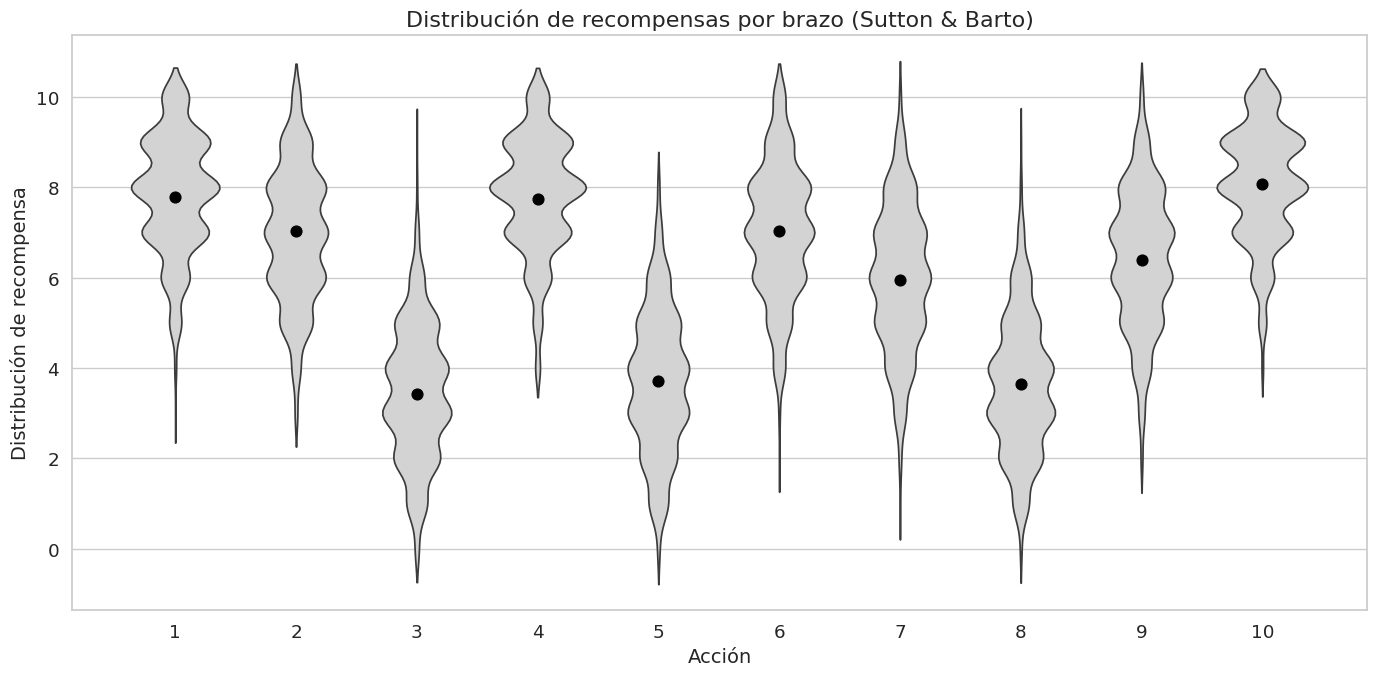

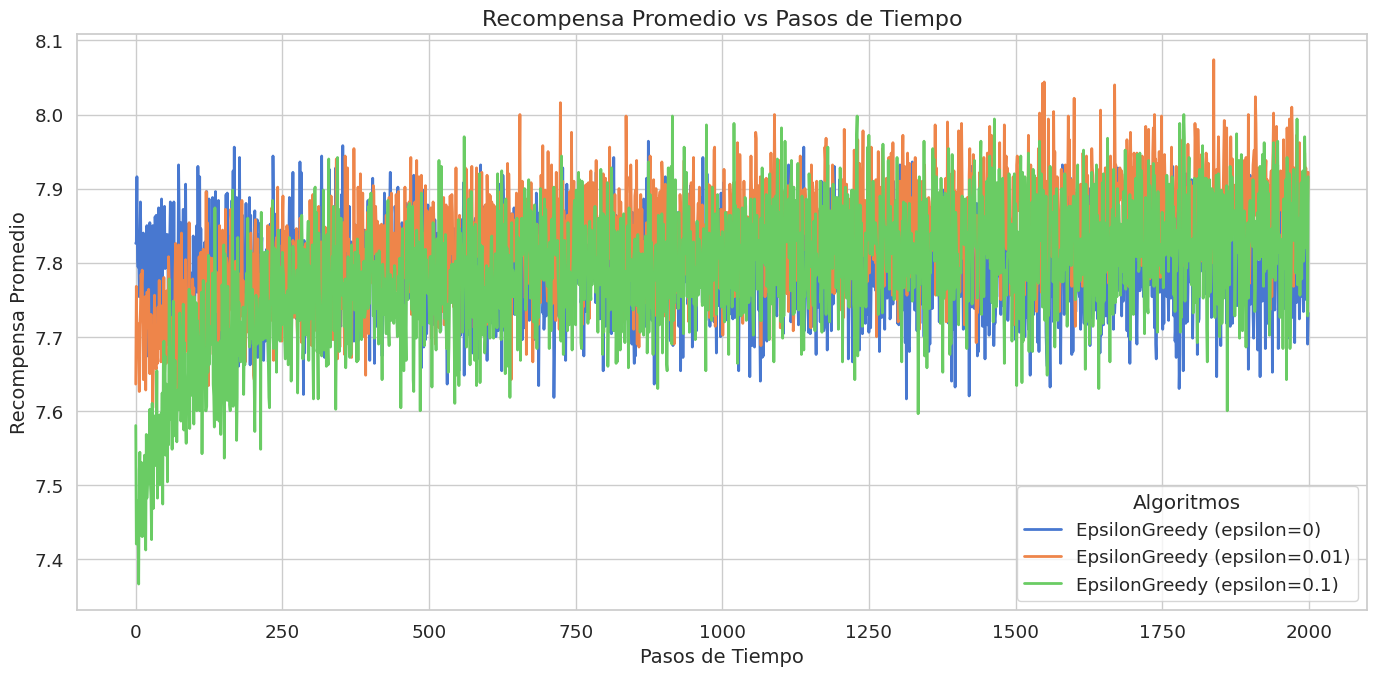

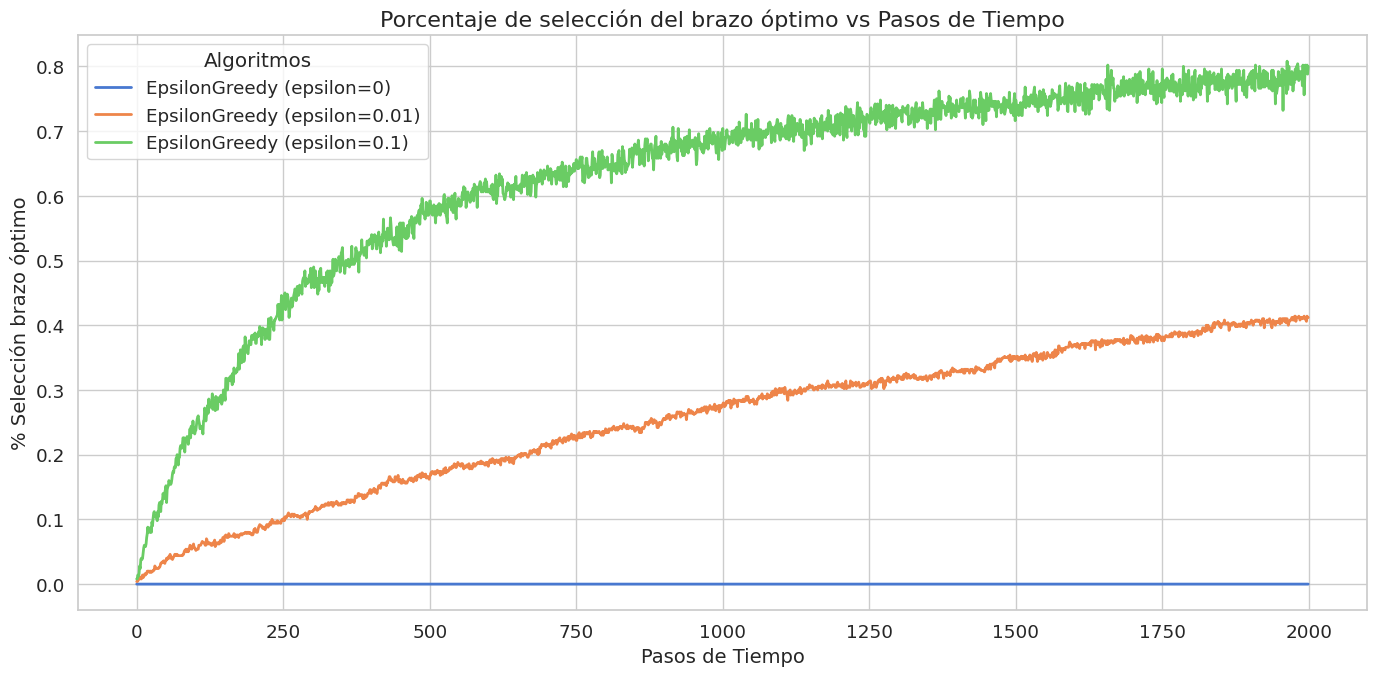


===== k = 20 =====


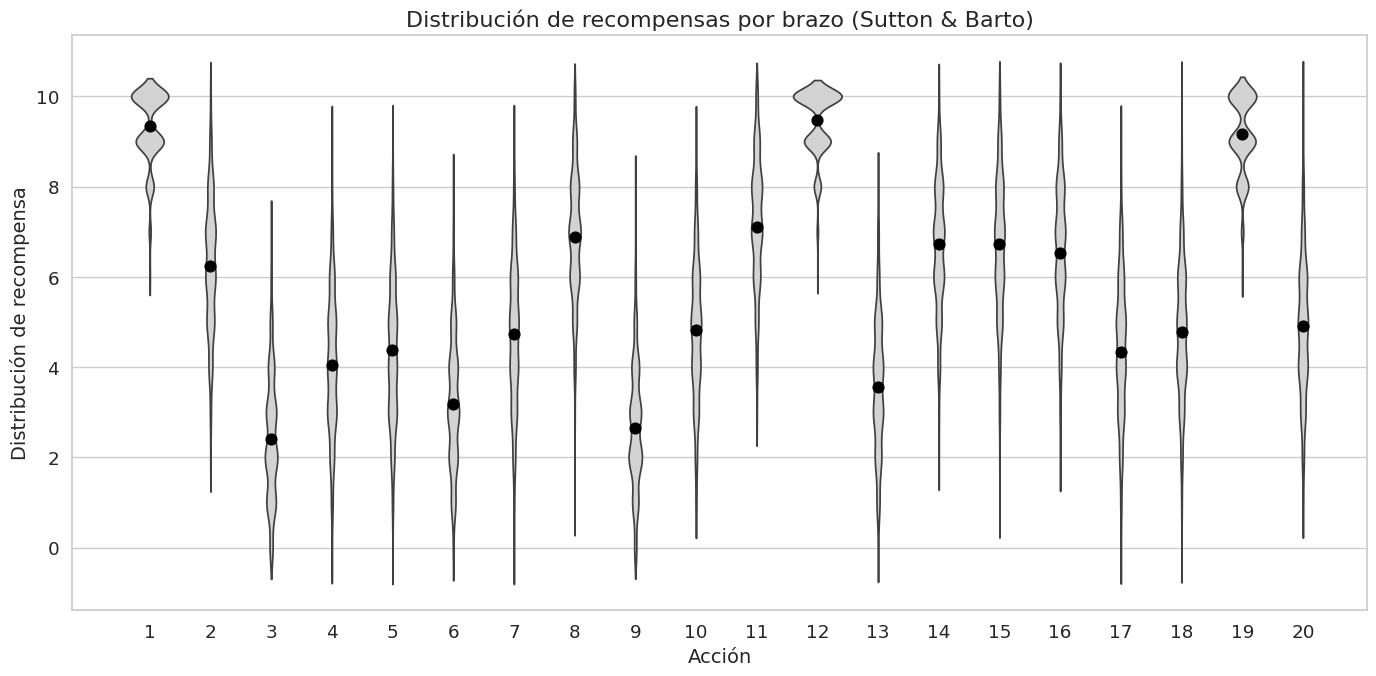

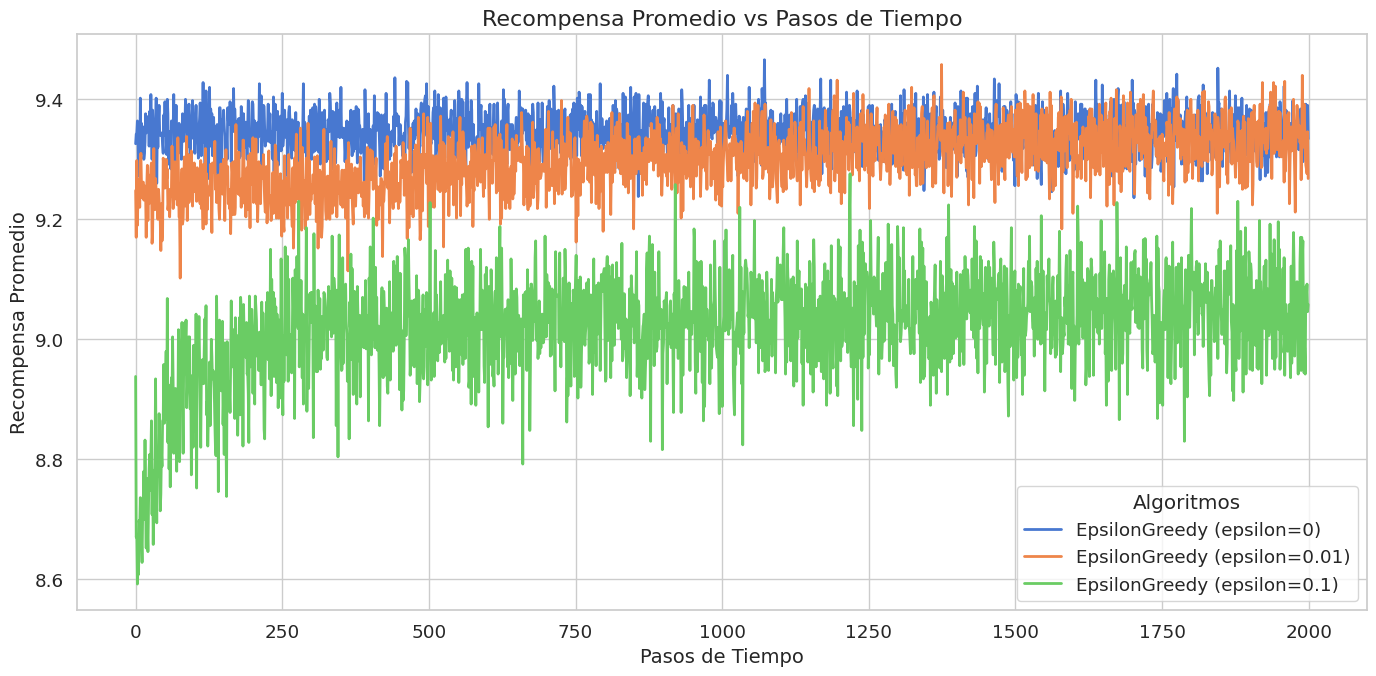

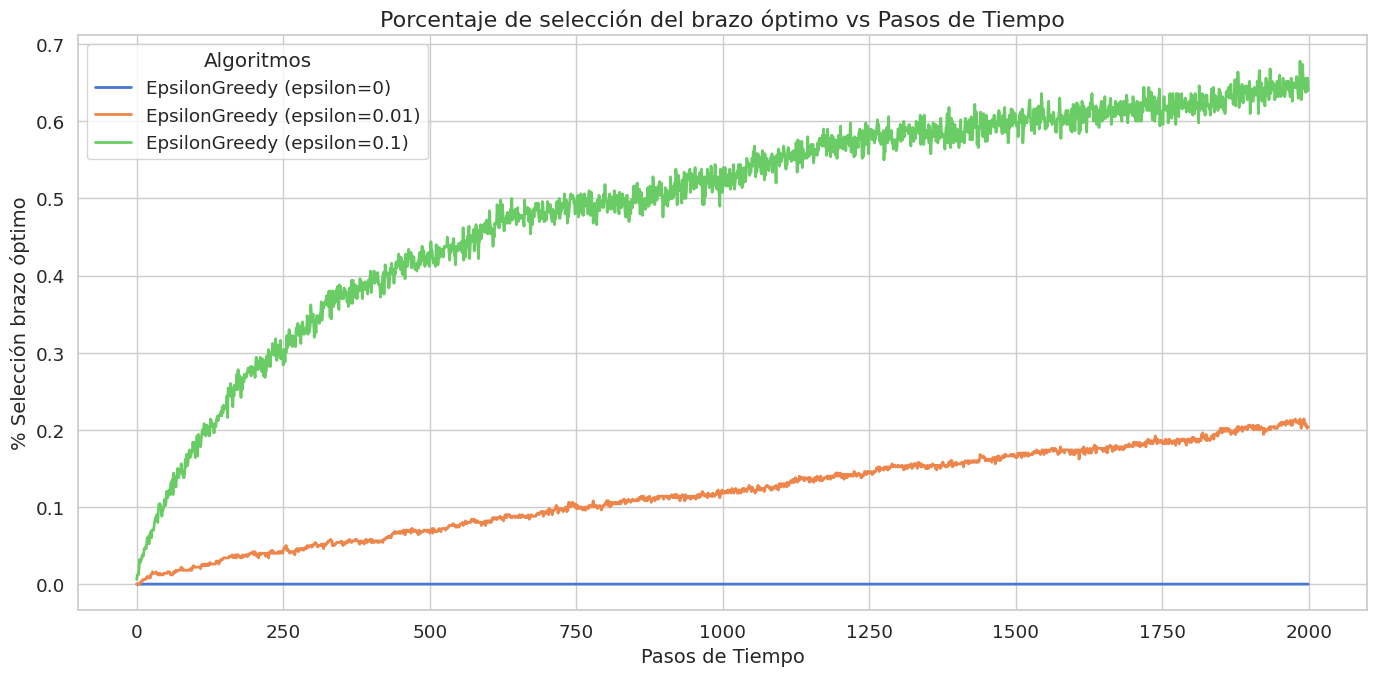


===== k = 100 =====


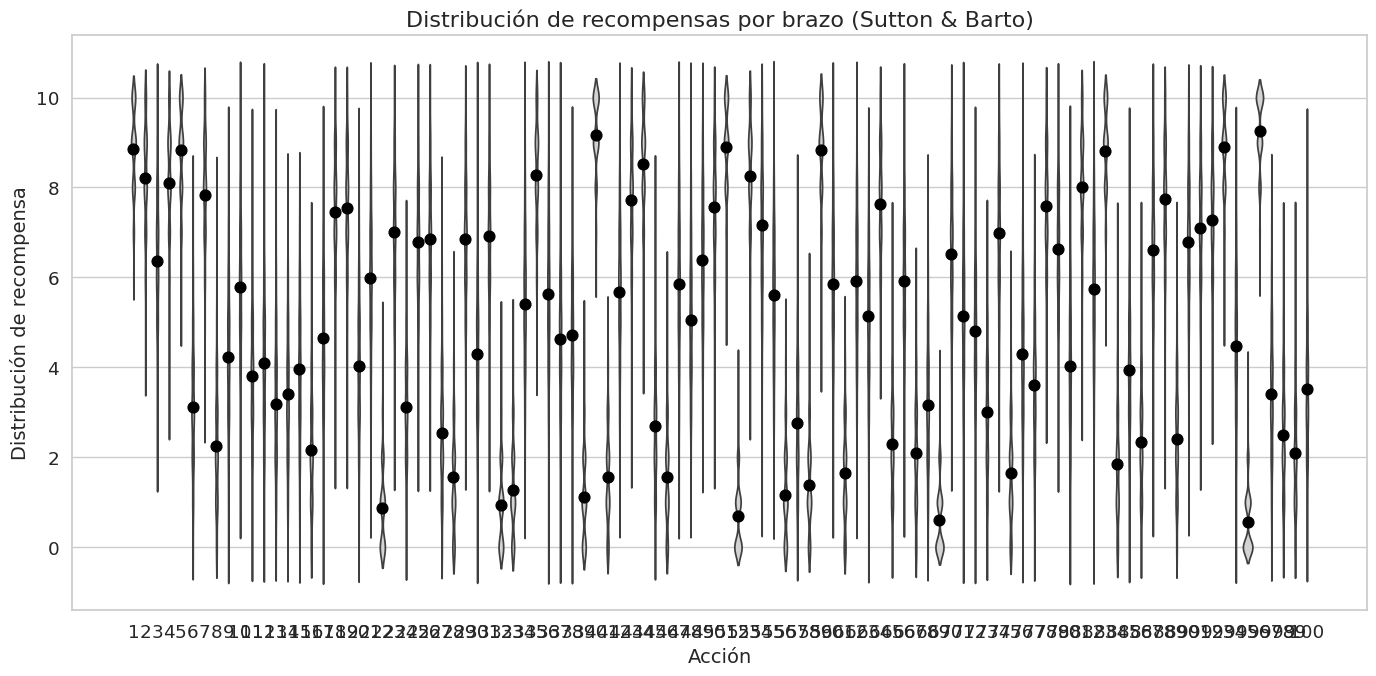

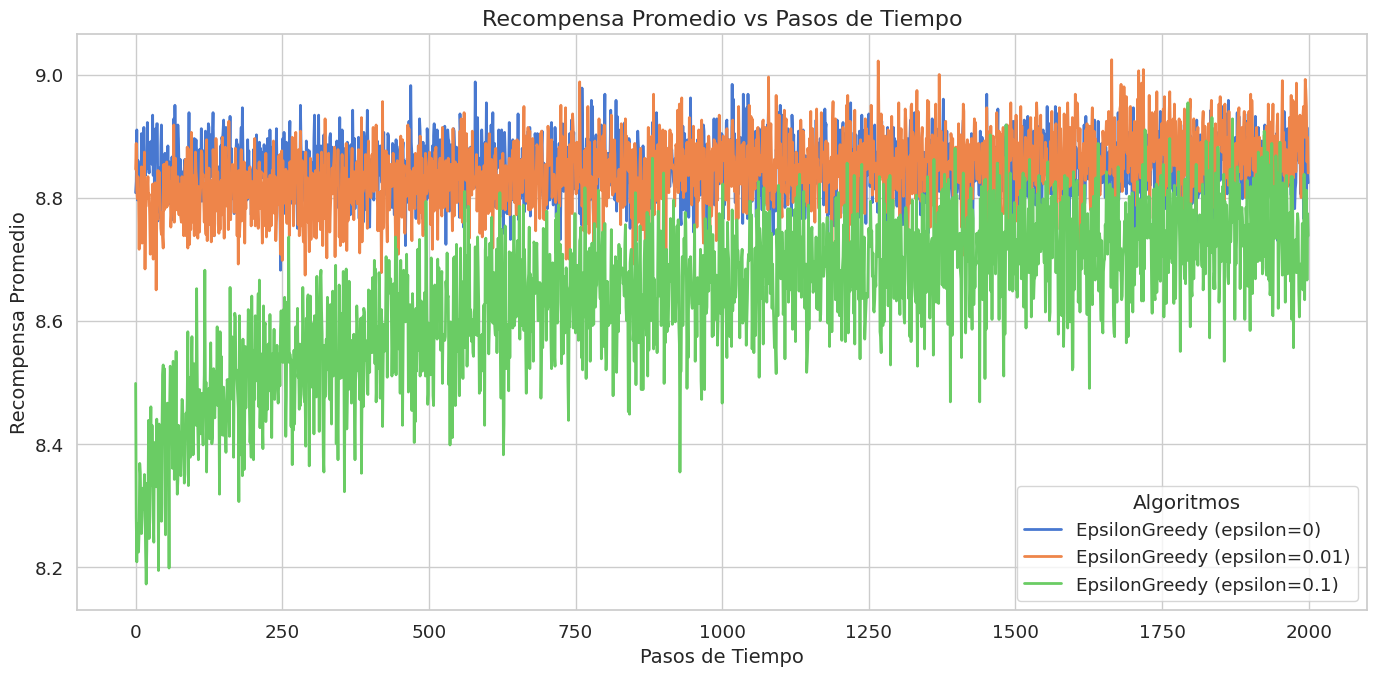

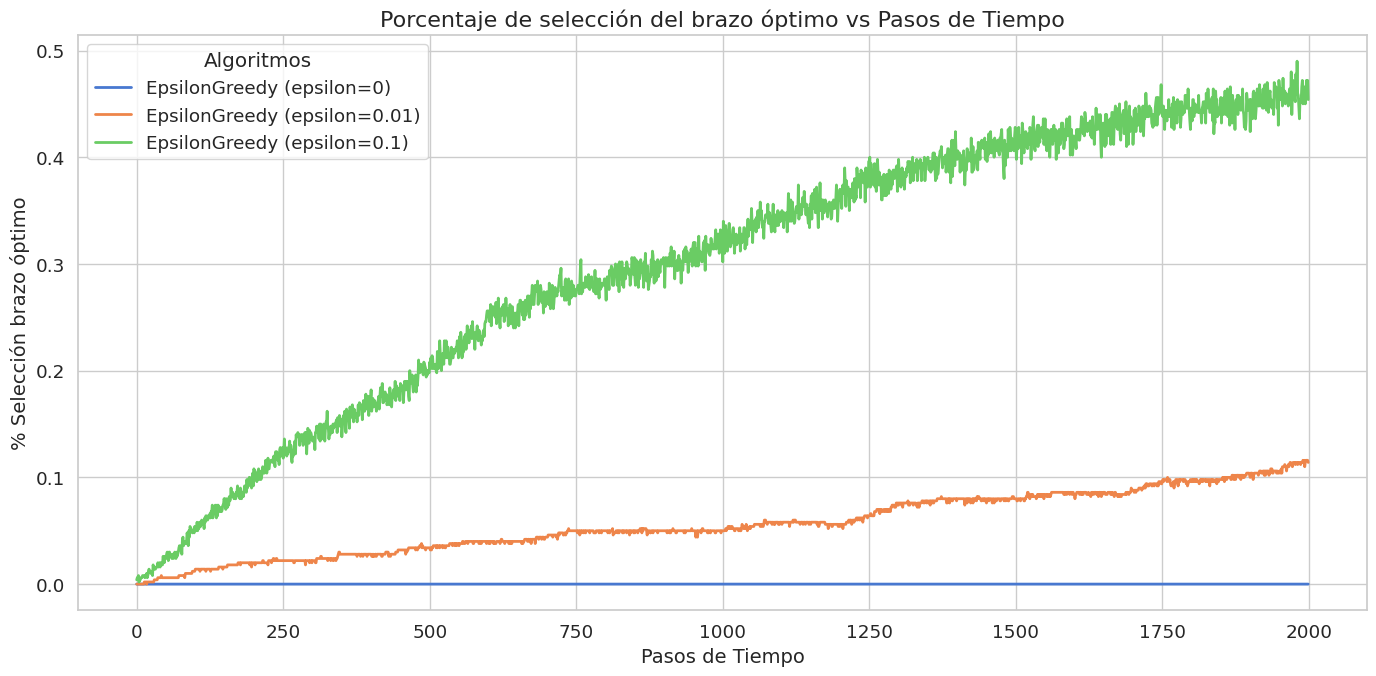

In [30]:
import numpy as np

from arms.armbinomial import ArmBinomial
from arms.bandit import Bandit
from algorithms.epsilon_greedy import EpsilonGreedy

from plotting.plotting import plot_average_rewards, plot_optimal_selections
from plotting.sutton import plot_reward_distributions


# =====================================================
# FUNCIÓN EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs

    return rewards, optimal_selections


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

n_fixed = 10   # mismo número de ensayos por brazo


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Generamos parámetros binomiales
    p_values = np.random.uniform(0.05, 0.95, k)
    arms = [ArmBinomial(n_fixed, p) for p in p_values]

    # 🔹 Gráfica Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 🔹 Gráficas oficiales del profesor
    plot_average_rewards(steps, rewards, algorithms)
    plot_optimal_selections(steps, optimal_selections, algorithms)

normal compelto


===== k = 10 =====


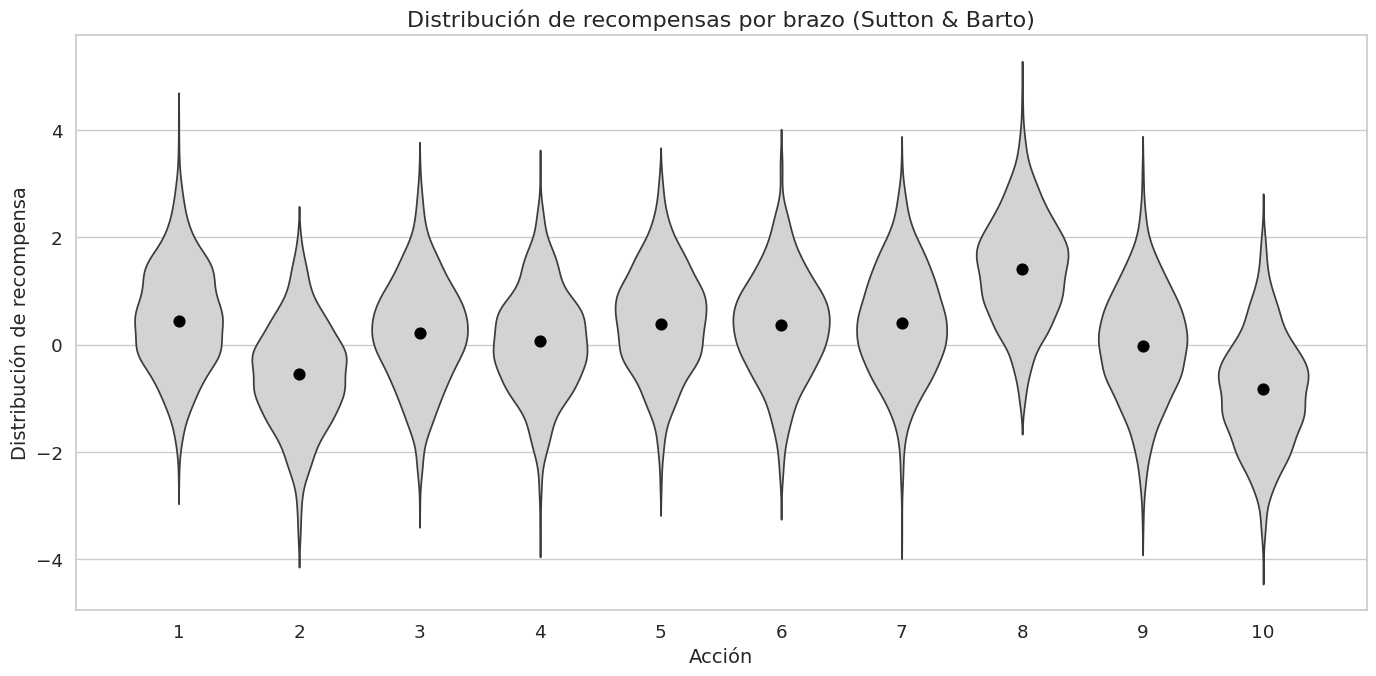

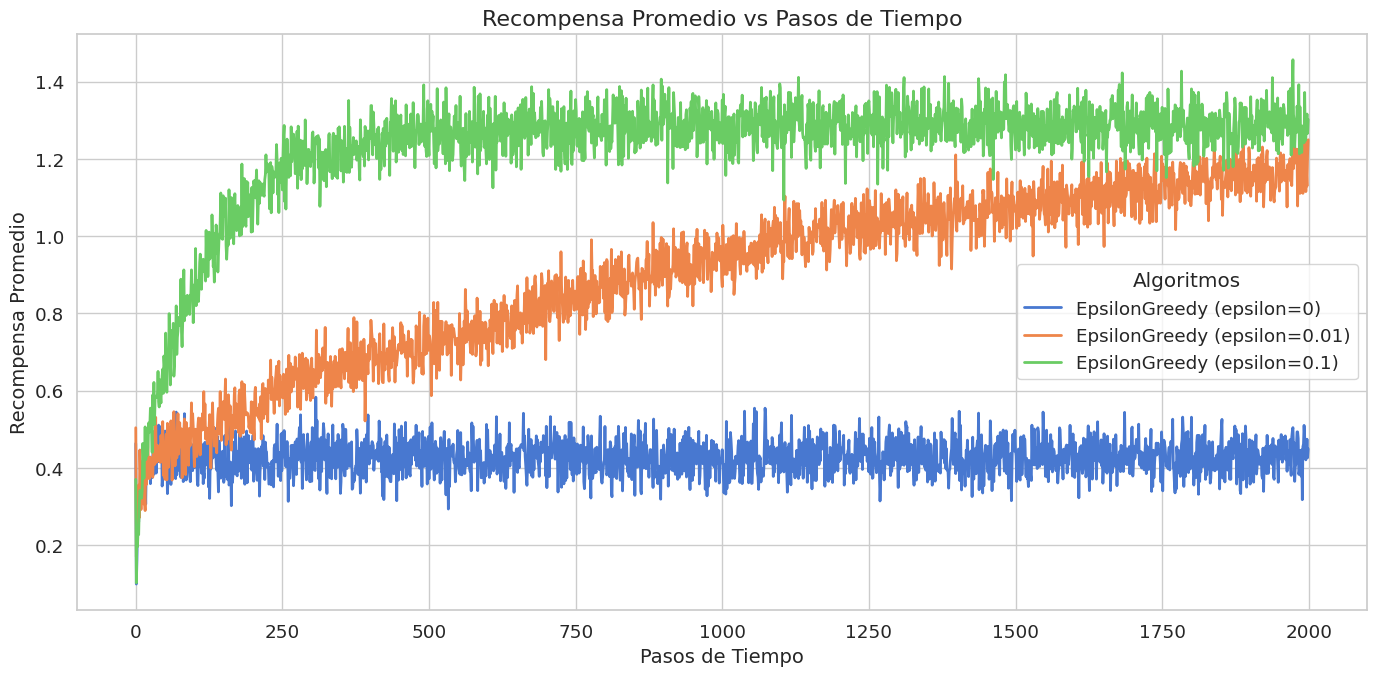

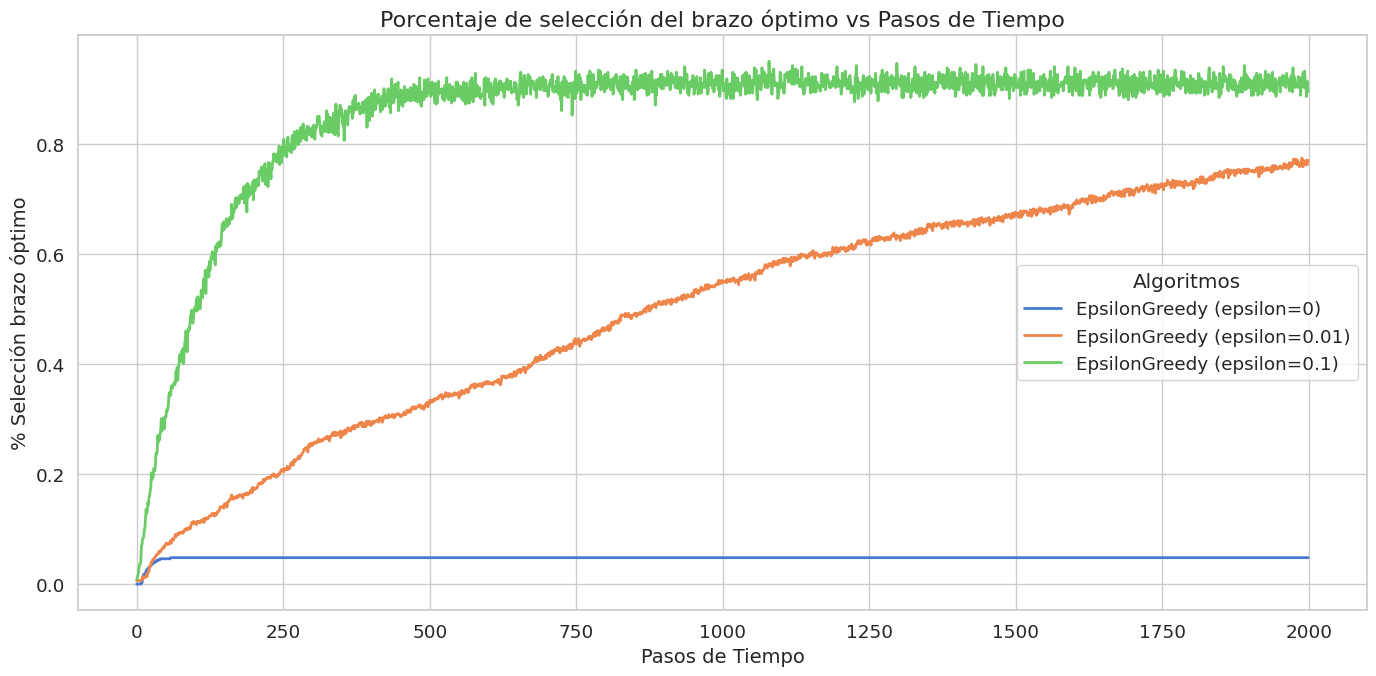


===== k = 20 =====


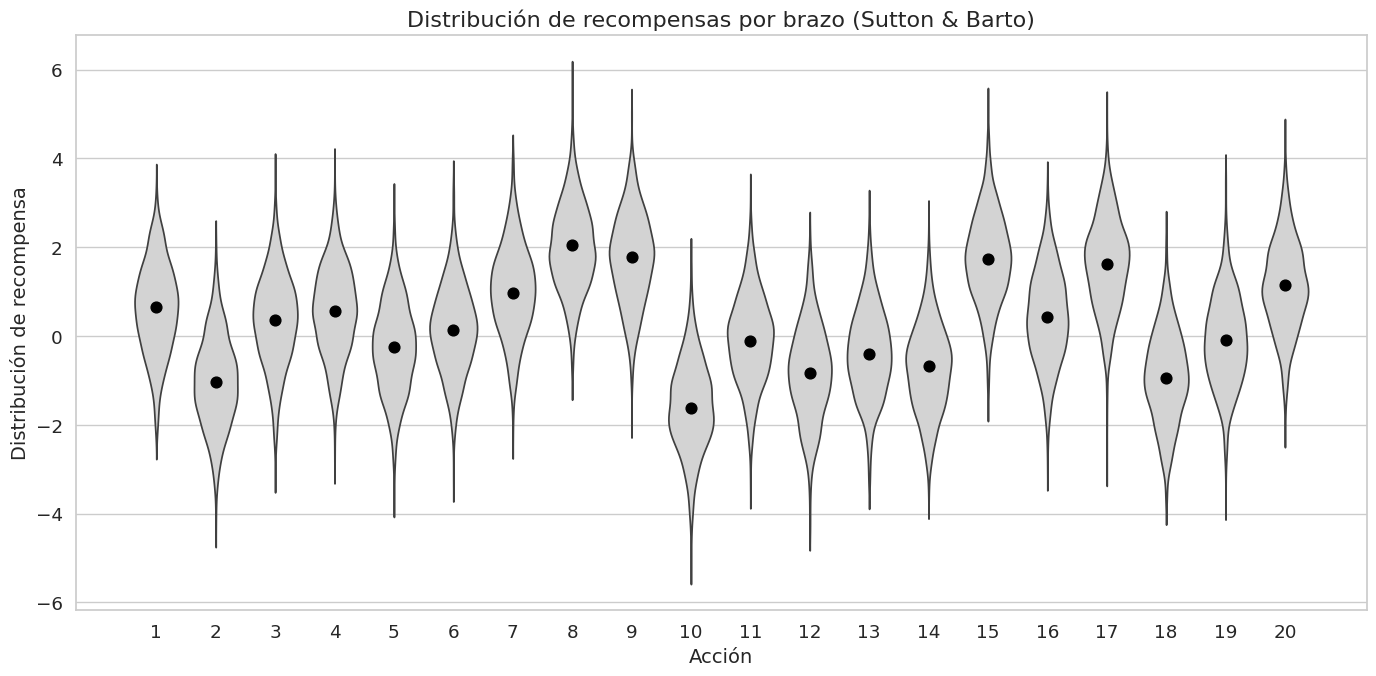

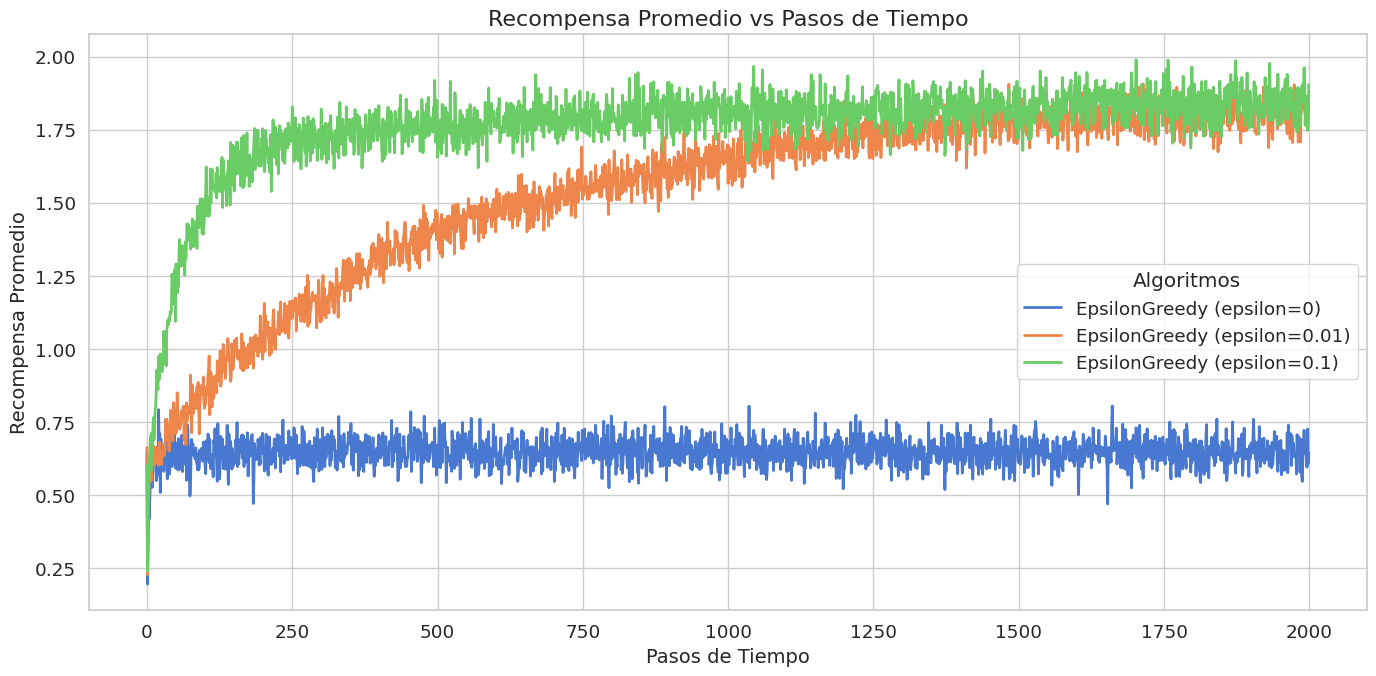

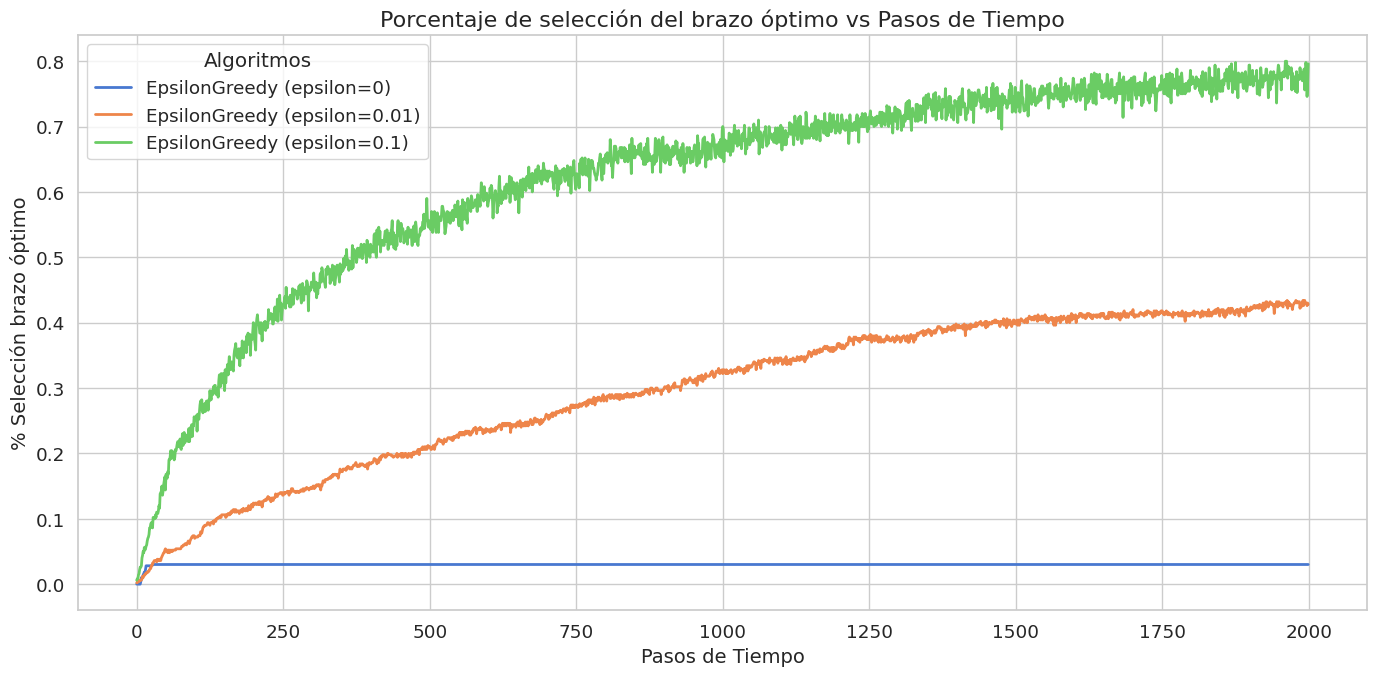


===== k = 100 =====


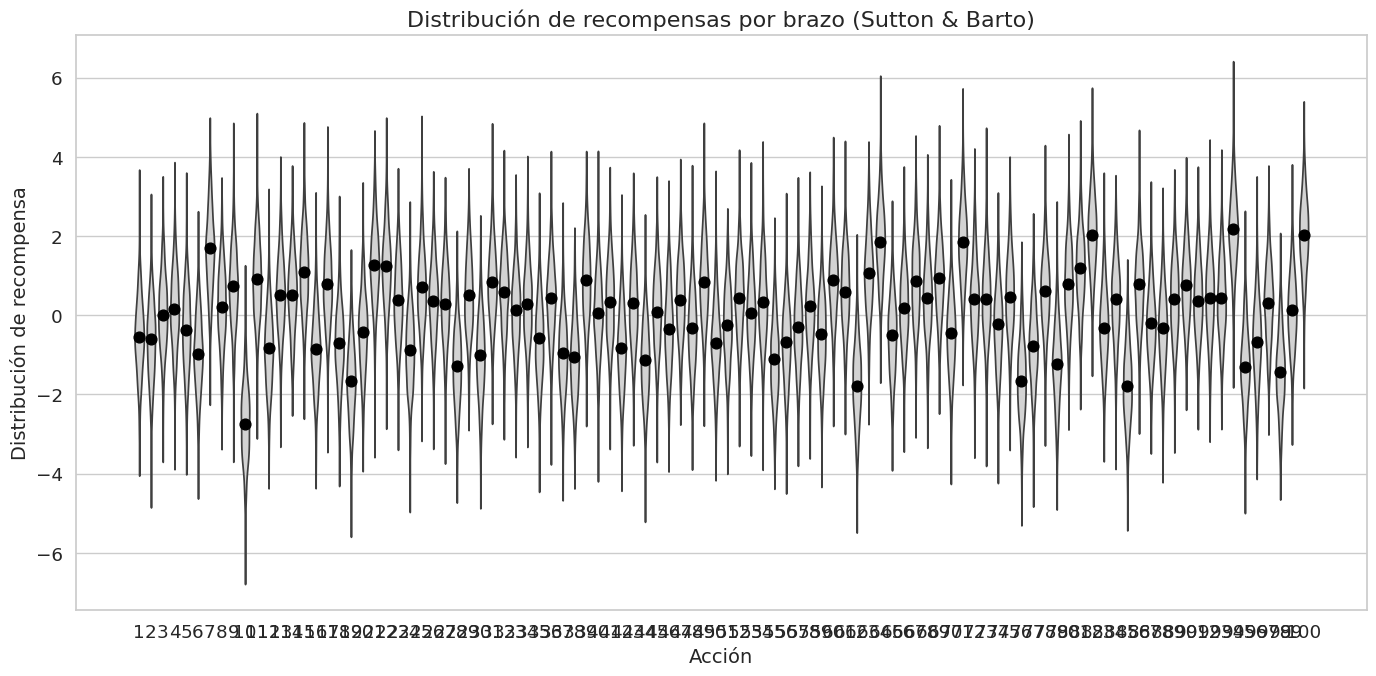

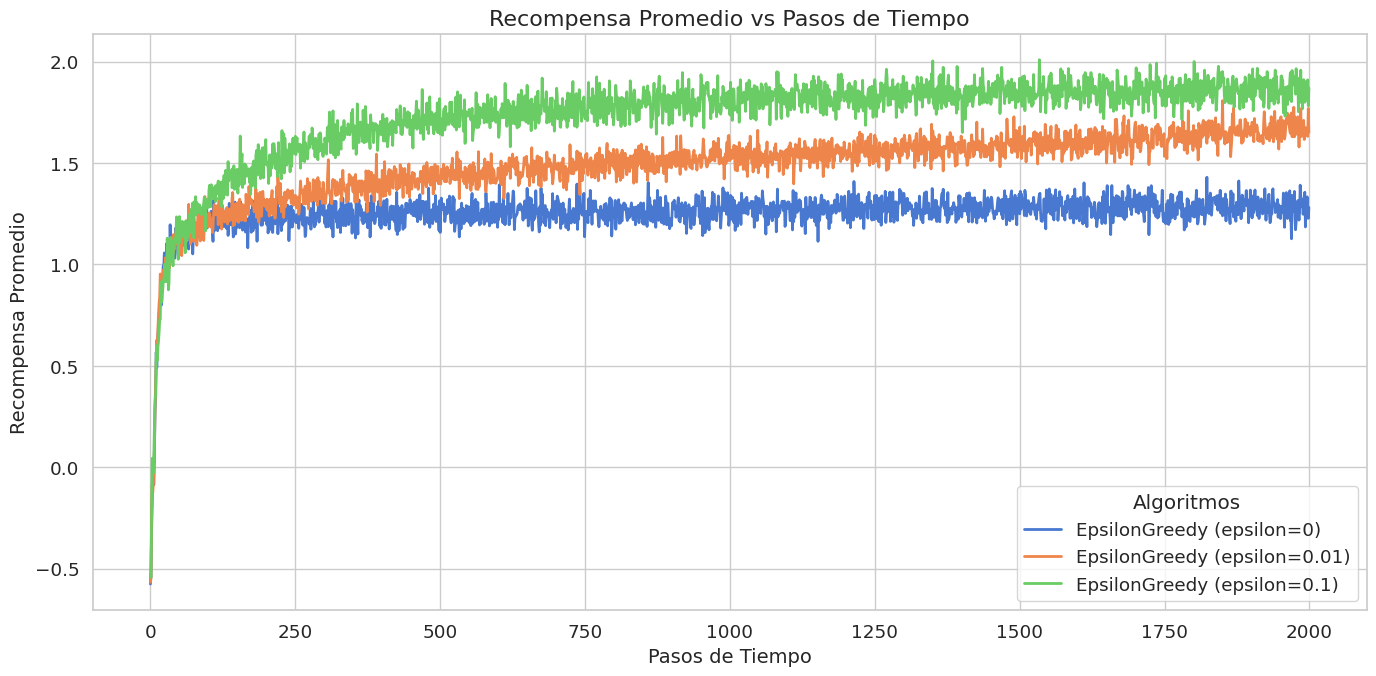

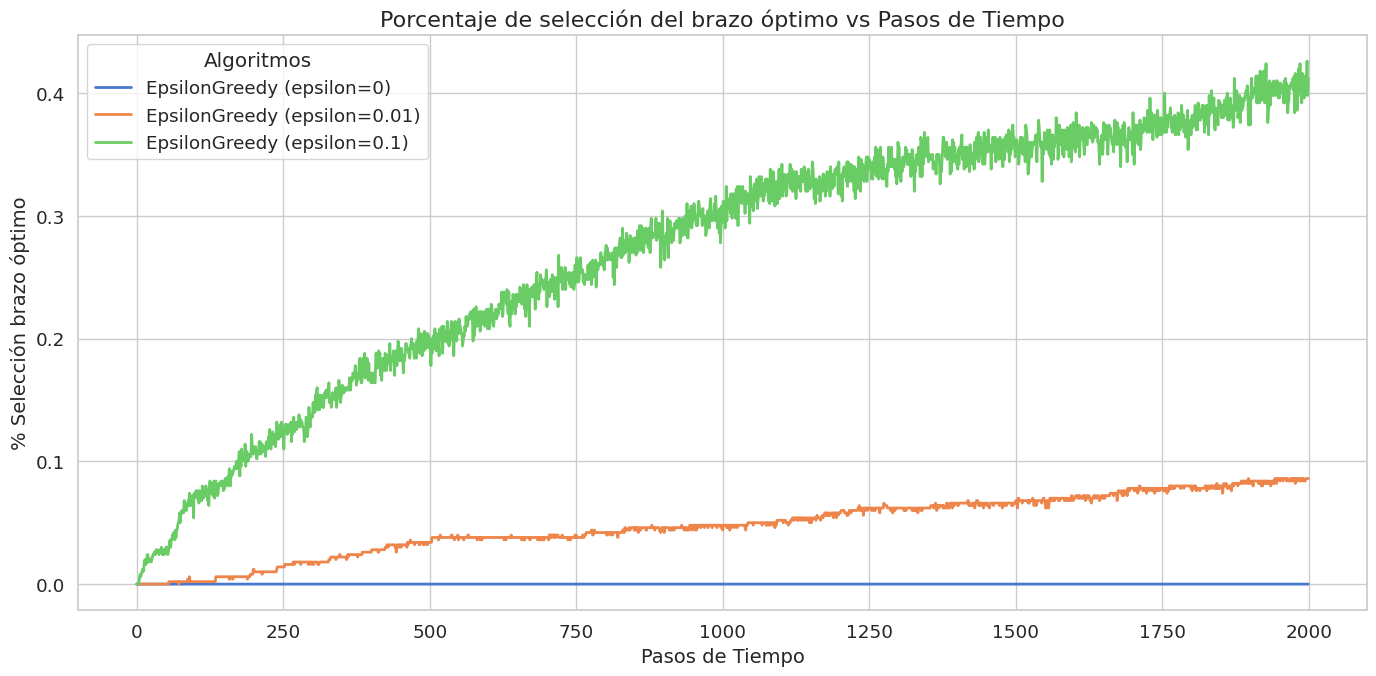

In [31]:
import numpy as np

from arms.armnormal import ArmNormal
from arms.bandit import Bandit
from algorithms.epsilon_greedy import EpsilonGreedy

from plotting.plotting import plot_average_rewards, plot_optimal_selections
from plotting.sutton import plot_reward_distributions


# =====================================================
# FUNCIÓN EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs

    return rewards, optimal_selections


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

sigma = 1   # Cambia a 50 o 100 si quieres estudiar efecto del ruido


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Generamos medias normales
    mu_values = np.random.normal(0, 1, k)
    arms = [ArmNormal(mu, sigma) for mu in mu_values]

    # 🔹 Gráfica tipo Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 🔹 Gráficas oficiales del profesor
    plot_average_rewards(steps, rewards, algorithms)
    plot_optimal_selections(steps, optimal_selections, algorithms)